# 03 — Formulae generation

Produces two figures:

* **Percentage of Equivalence between Formulae** + **Accuracy by Complexity**
* **Integrated Formulae Analysis: Type Distribution and Volume by Model Complexity**

Models were asked for *at least three different* formulae reproducing a numeric
sequence. Two things are measured, and they ask different questions.

**Accuracy** — does the formula, once evaluated, reproduce the target sequence?

**Equivalence** — do a model's *own* answers agree with each other? A model that
offers three formulae which evaluate to three different sequences has not
understood the sequence, whatever else it has done. Note this compares the
evaluated sequences, not the formula text: `n**2` and `n*n` are the same answer.

**No logic lives in this notebook.** Everything comes from `superarc.formulae`.

In [1]:
import pandas as pd
from superarc.notebook import figure

from superarc.formulae import (
    MODEL_ORDER,
    accuracy_table,
    add_measures,
    classify_content,
    equivalence_table,
    get_model_display_name,
    load,
    plot_equivalence_and_accuracy,
    plot_integrated,
    process_formula_data,
)
from superarc.registry import A_FORMULA, prefix_collisions

pd.set_option("display.width", 150)

df = load()
print(f"{len(df)} sequences x {len(df.columns)} columns, {len(MODEL_ORDER)} models")

90 sequences x 198 columns, 28 models


## The column grammar, and the defect it hid

Columns are named `<model><suffix>`: `gpt_4o`, `gpt_4o_1`, `gpt_4o_1_eval`. The
obvious way to collect one model's columns is `column.startswith(model)`, and
that is what the published figures did.

It is wrong, because **a model name is an atomic keyword, not a prefix**.
`gpt_4o` is a different model from `gpt_4o_mini`, but `startswith("gpt_4o")` is
true for both. Five models were therefore scored partly on a longer-named
model's answers:

In [2]:
prefix_collisions(A_FORMULA, list(df.columns))

,model,own columns,wrongly absorbed,examples
0,gpt_4o,7,7,"gpt_4o_mini, gpt_4o_mini_1, gpt_4o_mini_1_eval..."
1,gemini,7,13,"gemini-3-pro, gemini-3-pro_1, gemini-3-pro_1_e..."
2,mistral,5,10,"mistral-large-3, mistral-large-3_1, mistral-la..."
3,qwen,3,7,"qwen3, qwen3_1, qwen3_1_eval..."
4,deepseek,5,11,"deepseek_r1_0528, deepseek_r1_0528_1, deepseek..."


The resolver in `superarc.registry` matches **suffix-first, then longest name
wins**, which resolves all 196 columns of this dataset uniquely.

This is the correction behind the two figures below, and it moves real numbers —
DeepSeek's accuracy at complexity 2 goes from 16.19 to 43.33, and Qwen's
equivalence at complexity 1 from 42.22 to 0.00. The second is not a
deterioration: Qwen produced a single formula, and a single answer cannot agree
or disagree with itself. The published 42.22 was Qwen-3's answers counted as
Qwen's.

## Computing the measures

In [3]:
# verbose=True would print each model's resolved columns -- useful when
# checking the prefix fix, noise otherwise.
add_measures(df)

equiv_df = equivalence_table(df)
equiv_df.pivot(index="Model", columns="Complexity", values="Equivalence %").round(2)

/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:156: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'equivalence_{model}'] = df.apply(calc_row_equivalence, axis=1)
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:156: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'equivalence_{model}'] = df.apply(calc_row_equivalence, axis=1)
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:156: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:201: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[accuracy_col] = df.apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

...

/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{model}_number_formula'] = df[eval_cols].apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{model}_number_formula'] = df[eval_cols].apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

evaluation columns for grok4: ['grok4_1_eval', 'grok4_2_eval', 'grok4_3_eval']
evaluation columns for qwen: ['qwen_1_eval']
evaluation columns for deepseek: ['deepseek_1_eval', 'deepseek_2_eval']
evaluation columns for chatgpt_4.5: ['chatgpt_4.5_1_eval', 'chatgpt_4.5_2_eval', 'chatgpt_4.5_3_eval']
evaluation columns for claude_3.7: ['claude_3.7_1_eval', 'claude_3.7_2_eval', 'claude_3.7_3_eval']
evaluation columns for deepseek_r1_0528: ['deepseek_r1_0528_1_eval', 'deepseek_r1_0528_2_eval', 'deepseek_r1_0528_3_eval', 'deepseek_r1_0528_4_eval', 'deepseek_r1_0528_5_eval']
evaluation columns for llama_4_scout: ['llama_4_scout_1_eval', 'llama_4_scout_2_eval', 'llama_4_scout_3_eval']
evaluation columns for qwen3: ['qwen3_1_eval', 'qwen3_2_eval', 'qwen3_3_eval']
evaluation columns for chatgpt_5: ['chatgpt_5_1_eval', 'chatgpt_5_2_eval', 'chatgpt_5_3_eval', 'chatgpt_5_4_eval', 'chatgpt_5_5_eval']
evaluation columns for opus_4: ['opus_4_1_eval', 'opus_4_2_eval', 'opus_4_3_eval']
evaluation column

evaluation columns for gpt-5.2: ['gpt-5.2_1_eval', 'gpt-5.2_2_eval']
evaluation columns for claude-4.5: ['claude-4.5_1_eval', 'claude-4.5_2_eval', 'claude-4.5_3_eval']
evaluation columns for gemini-3-pro: ['gemini-3-pro_1_eval']
evaluation columns for mistral-large-3: ['mistral-large-3_1_eval']


/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{model}_number_formula'] = df[eval_cols].apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{model}_number_formula'] = df[eval_cols].apply(
/Users/alberto/Documents/projects/medLLM/superarc/formulae.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

Complexity,1,2,3
Model,,,
chatgpt_4.5,57.78,20.00,0.00
chatgpt_5,64.44,14.44,13.33
claude-4.5,36.67,41.11,0.00
claude_3.5,100.00,1.11,0.00
claude_3.7,28.89,3.33,0.00
claude_sonnet_4,64.44,8.89,15.44
cursor_small,16.67,10.00,0.00
deepseek,3.33,26.67,0.00
deepseek_r1_0528,58.89,11.11,12.22


In [4]:
accuracy = accuracy_table(df)
accuracy.round(2).T

Complexity,1,2,3
accuracy-percentage-gpt_4o,46.67,21.11,0.0
accuracy-percentage-gpt_4o_mini,43.33,14.44,0.0
accuracy-percentage-gemini_2.5_pro,43.33,11.11,0.0
accuracy-percentage-gemini,47.78,14.44,0.0
accuracy-percentage-claude_3.5,75.56,15.56,0.0
accuracy-percentage-o1_preview,66.67,28.89,0.0
accuracy-percentage-mistral,50.00,11.67,0.0
accuracy-percentage-meta,81.67,11.67,0.0
accuracy-percentage-cursor_small,38.89,18.89,0.0
accuracy-percentage-o1_mini,90.00,28.33,0.0


Read down either table: both collapse toward zero as complexity rises. By
complexity 3 most models neither reproduce the sequence nor agree with
themselves.

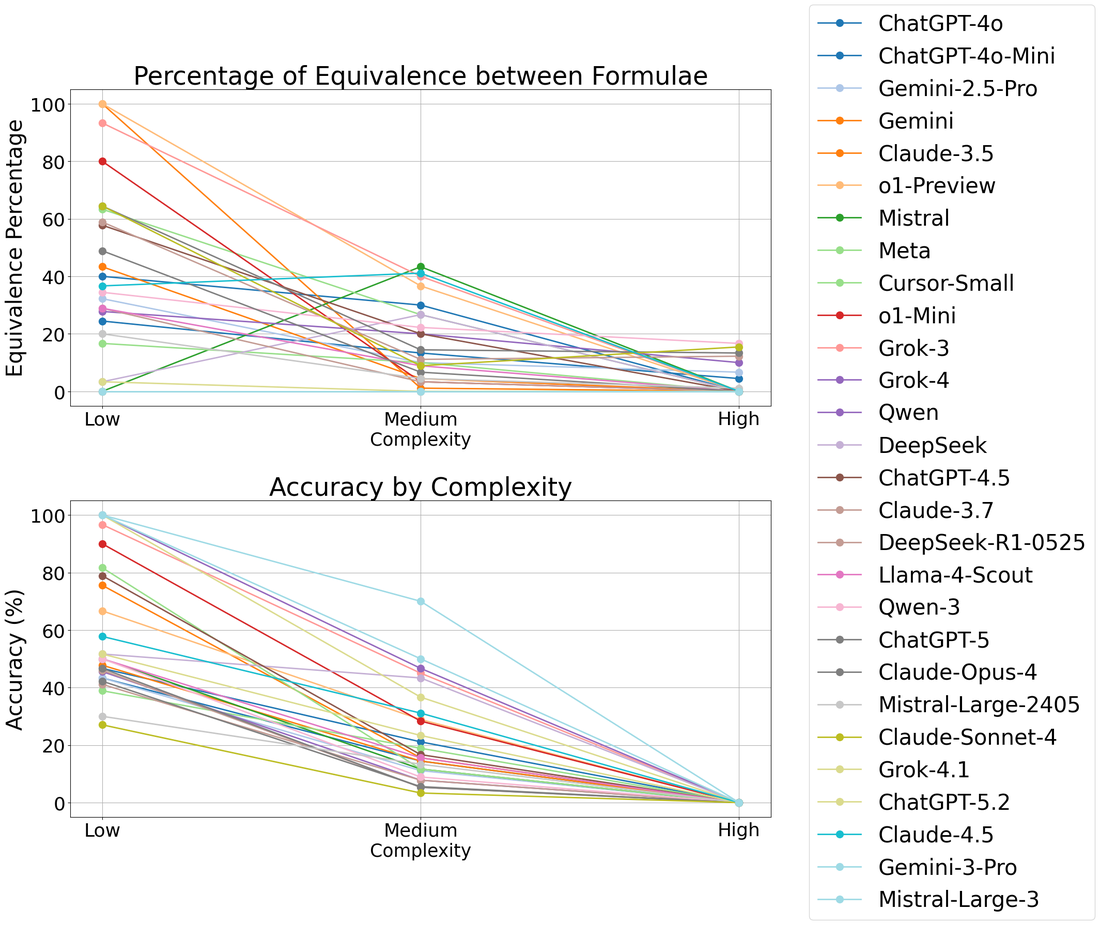

In [5]:
written = plot_equivalence_and_accuracy(df, equiv_df)
for path in written if isinstance(written, list) else []:
    print(path)

figure("figure03-up.png")

## What kind of answers were they?

Every raw answer is labelled by content:

| label | meaning |
|---|---|
| **Known sequence** | names a standard object — Fibonacci, primes, Catalan, … |
| **Pure math** | an expression, no named sequence |
| **Not found** | the model produced nothing usable |

The classifier is keyword-based and deliberately crude; it is reported as
published.

In [6]:
pd.DataFrame(
    {"answer": ["Fibonacci sequence", "a(n) = n**2 + 1", "*not found", "Catalan numbers"]}
).assign(classified=lambda d: d["answer"].map(classify_content))

,answer,classified
0,Fibonacci sequence,Known sequence
1,a(n) = n**2 + 1,Pure math
2,*not found,Not found
3,Catalan numbers,Known sequence


In [7]:
volume, total_class, accurate_class = process_formula_data(df)

summary = (total_class.pivot_table(index="Model", columns="Classification",
                                   values="Count", aggfunc="sum")
           .join(volume.groupby("Model")["Count"].sum().rename("Valid formulae")))
summary.index = [get_model_display_name(m) for m in summary.index]
summary.sort_values("Valid formulae", ascending=False).head(12)

,Known sequence,Not found,Pure math,Valid formulae
ChatGPT-4o-Mini,18,0,252,270
Grok-4,9,0,261,270
Mistral-Large-2405,51,0,219,270
Llama-4-Scout,87,0,183,270
Qwen-3,18,0,252,270
Claude-3.7,51,0,219,270
Gemini-2.5-Pro,9,0,260,269
Claude-Opus-4,31,0,189,220
DeepSeek-R1-0525,13,0,184,197
Claude-Sonnet-4,11,0,178,189


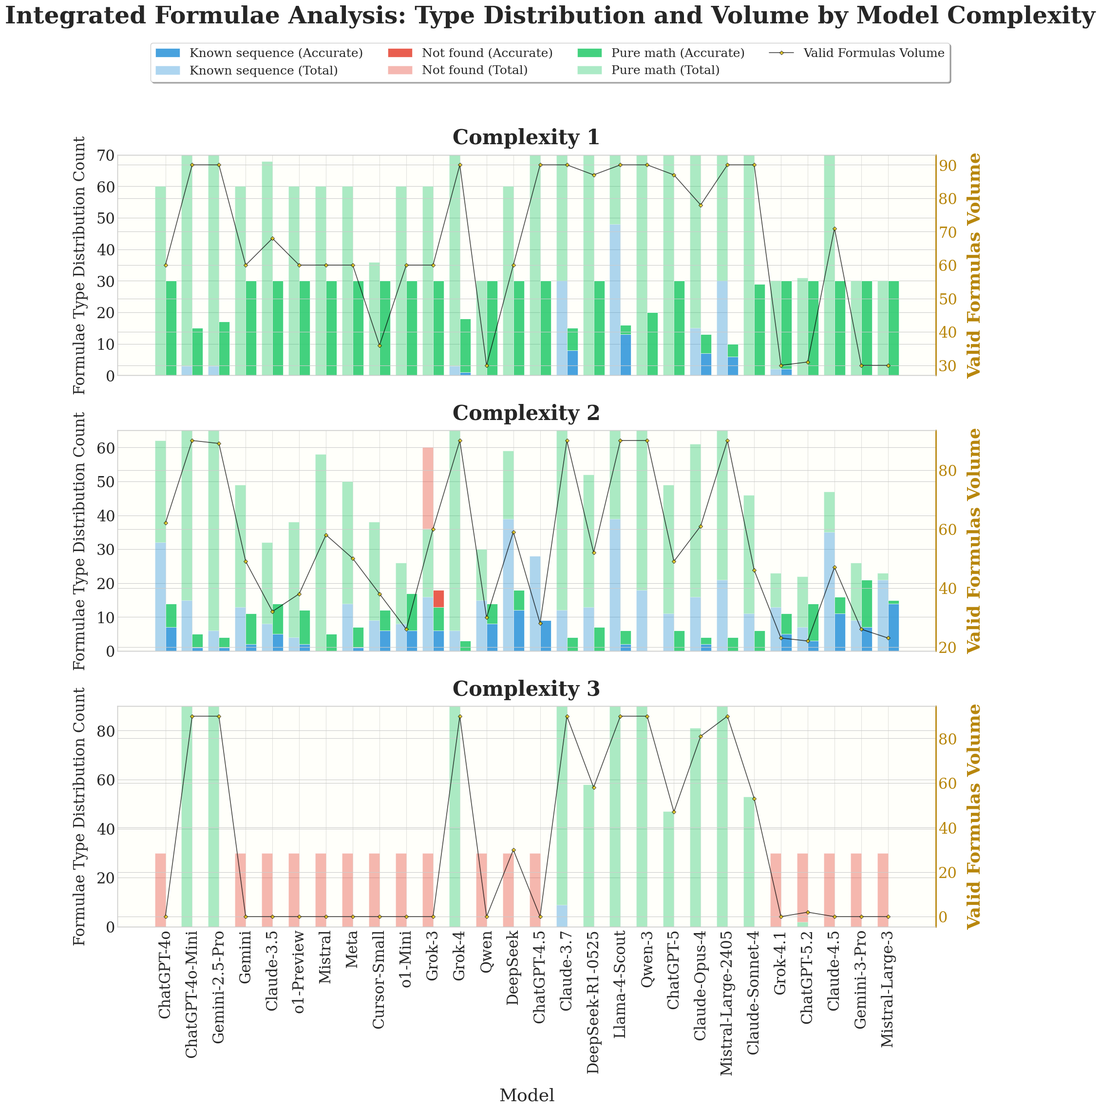

In [8]:
plot_integrated(df)
figure("figure03-bottom.png")

## Verification

Both figures are **authorised changes**: they deliberately no longer match what
was printed, because the printed versions carried the prefix collision shown
above. They are still held to run-to-run determinism, so an unintended change on
top of an authorised one is still caught.

In [9]:
from superarc.parity import check_figures

check_figures(["figure03-up.png", "figure03-bottom.png"])

,figure,status,detail
0,figure03-up.png,changed,Fig 3 formulae -- CORRECTED: columns were mat...
1,figure03-bottom.png,changed,Fig 4 integrated formulae -- CORRECTED: same ...


In [10]:
import subprocess

dirty = subprocess.run(
    ["git", "status", "--porcelain", "new_plots/", "plots/"],
    capture_output=True, text=True,
).stdout.strip()

print(dirty if dirty else "clean: no published figure was modified")

clean: no published figure was modified


### Where this code lives

`30-1_multiFormula_experiment.py` is now a forwarder onto `superarc.formulae`.
It is kept, not deleted, because it is the path that produced the published
figures and every result in the paper traces to that name.

Before the move the module was checked against the script: **both figures at
0.0000% pixel difference, and the emitted summary CSV byte-identical across 588
rows** — including with the two plotting calls in reverse order, which exposed a
real latent defect. The script set matplotlib styles as global statements
*between* the two figures, so calling them the other way round silently
restyled one. Each figure sets its own style now.